# Autoencoder Training

This notebook trains a convolutional autoencoder on **normal data** (no chatter).  
The model learns a compact representation and attempts to reconstruct the input images.  
Because anomalous samples (chatter) are not seen during training, we expect them to yield a **higher reconstruction error**.

**Core idea:** anomaly score = reconstruction error (e.g., MSE) between the input and its reconstruction.

In [10]:
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import plotly.express as px 

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found.")


No GPU found.


## Data

The spectrograms are loaded as images.

We distinguish between:
- **GOOD / Normal**: samples without chatter (used for training)
- **BAD / Chatter**: potentially anomalous samples (typically used for evaluation)

This notebook trains the autoencoder using **only the normal (GOOD)** class.

In [7]:
#DATA_GOOD = "../data/02_spectrograms_150x100px_dataset/train/no_chatter"
DATA_GOOD = "../../data/03_broach_dataset/train/"

In [8]:
def load_images_from_folder(folder, target_size=(150, 100)):
    images = []
    valid_ext = (".png", ".jpg", ".jpeg")

    for file in tqdm(os.listdir(folder)):
        if file.lower().endswith(valid_ext):
            path = os.path.join(folder, file)

            img = (
                Image.open(path)
                .convert("RGB")
                .resize(target_size)
            )

            images.append(np.array(img))

    return np.array(images)

Load only normal data!

In [12]:
images = load_images_from_folder(DATA_GOOD)

images = images.astype(np.float32) / 255.0

print("Loaded normal samples:", images.shape)

x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train:", x_train.shape)
print("Val:", x_val.shape)

# NHWC -> NCHW
x_train = np.transpose(x_train, (0, 3, 1, 2))
x_val = np.transpose(x_val, (0, 3, 1, 2))

print("PyTorch shape:", x_train.shape)

100%|██████████| 5000/5000 [06:19<00:00, 13.18it/s]


Loaded normal samples: (5000, 100, 150, 3)
Train: (4000, 100, 150, 3)
Val: (1000, 100, 150, 3)
PyTorch shape: (4000, 3, 100, 150)


## Visualization / Sanity Check

To verify the data pipeline, we visualize one example spectrogram from the training set.
This helps confirm that resizing and normalization behave as expected.

In [21]:
print(x_train.shape)


x = torch.randn(1, 3, 100, 150)

with torch.no_grad():
    y = model.encoder_conv(x)

print(y.shape)


(4000, 3, 100, 150)
torch.Size([1, 12, 25, 25])


In [13]:
img = x_train[1120].transpose(1, 2, 0)

fig = px.imshow(img)
fig.update_layout(coloraxis_showscale=False)
fig.show()

## Model: Convolutional Autoencoder

The autoencoder consists of three parts: 

1. **Encoder**: extracts features using convolutions and progressively reduces spatial dimensions
2. **Bottleneck**: compresses the representation using a dense layer
3. **Decoder**: reconstructs the input via dense expansion, reshaping, upsampling, and convolutions

### Training objective
The model minimizes the reconstruction error (MSE) between the input image $x$ and its reconstruction $\hat{x}$.

During anomaly detection, the reconstruction error is used as an anomaly score.

In [14]:
# Dataloader 
batch_size = 512

train_dataset = TensorDataset(torch.tensor(x_train))
val_dataset = TensorDataset(torch.tensor(x_val))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 4, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(4, 8, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=(2, 3), stride=(2, 3)),

            nn.Conv2d(8, 12, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()

        self.encoder_fc = nn.Sequential(
            nn.Linear(12 * 25 * 25, 16),
            nn.ReLU()
        )

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(16, 12 * 25 * 25),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.Conv2d(12, 12, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 3), mode='nearest'),

            nn.Conv2d(12, 8, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 2), mode='nearest'),

            nn.Conv2d(8, 4, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(4, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder_conv(x)

        x = self.flatten(x)

        latent = self.encoder_fc(x)

        x = self.decoder_fc(latent)

        x = x.view(-1, 12, 25, 25)

        x = self.decoder_conv(x)

        return x

In [16]:
model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 3), stride=(2, 3), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_fc): Sequential(
    (0): Linear(in_features=7500, out_features=16, bias=True)
    (1): ReLU()
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=16, out_features=7500, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=(2.0, 3.0), mode='nearest')
    (3): Conv2d(12, 8, kernel_size=(3, 3), stride=(1, 1), pad

## Training Setup

- **Optimizer:** Adam with a small learning rate
- **Loss:** Mean Squared Error (MSE), measuring reconstruction quality

Because the autoencoder is trained on normal data only, anomalous inputs are expected to produce larger reconstruction errors.

In [28]:
loss='mse'
#-----------
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

#------------
epochs = 4000

train_losses = []
val_losses = []

for epoch in range(epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    running_loss = 0.0

    for (batch,) in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        outputs = model(batch)

        loss = criterion(outputs, batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # --------------------
    # Validation
    # --------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for (batch,) in val_loader:

            batch = batch.to(device)

            outputs = model(batch)

            loss = criterion(outputs, batch)

            running_val_loss += loss.item() * batch.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Val Loss: {val_loss:.6f}"
        )


Epoch [1/4000] Train Loss: 0.029748 Val Loss: 0.029478
Epoch [11/4000] Train Loss: 0.026000 Val Loss: 0.025769
Epoch [21/4000] Train Loss: 0.022862 Val Loss: 0.022666
Epoch [31/4000] Train Loss: 0.020227 Val Loss: 0.020058
Epoch [41/4000] Train Loss: 0.017999 Val Loss: 0.017854
Epoch [51/4000] Train Loss: 0.016105 Val Loss: 0.015979
Epoch [61/4000] Train Loss: 0.014485 Val Loss: 0.014375
Epoch [71/4000] Train Loss: 0.013093 Val Loss: 0.012995
Epoch [81/4000] Train Loss: 0.011889 Val Loss: 0.011802
Epoch [91/4000] Train Loss: 0.010842 Val Loss: 0.010766
Epoch [101/4000] Train Loss: 0.009929 Val Loss: 0.009860
Epoch [111/4000] Train Loss: 0.009128 Val Loss: 0.009067
Epoch [121/4000] Train Loss: 0.008423 Val Loss: 0.008367
Epoch [131/4000] Train Loss: 0.007800 Val Loss: 0.007749
Epoch [141/4000] Train Loss: 0.007246 Val Loss: 0.007200
Epoch [151/4000] Train Loss: 0.006754 Val Loss: 0.006712
Epoch [161/4000] Train Loss: 0.006313 Val Loss: 0.006275


KeyboardInterrupt: 

## Reconstruction on a Sample

To qualitatively verify the training, we select a single validation sample and run the autoencoder to obtain its reconstruction.  
We then compute the reconstruction error (MSE) between the original input and the reconstructed output.


Reconstruction MSE: 0.006074


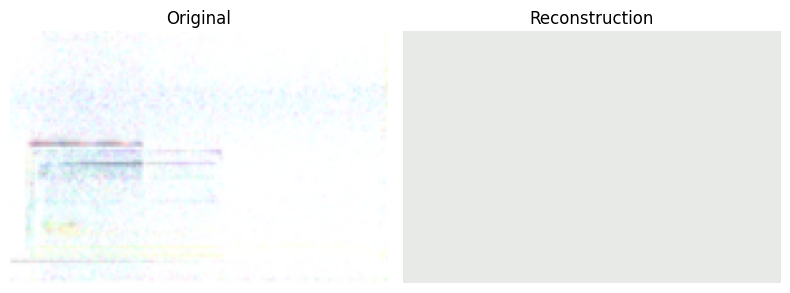

In [29]:

# -----------------------------
# Sample selection
# -----------------------------
idx = 62

sample = x_val[idx]                    # Shape: (3, H, W)
sample_input = np.expand_dims(sample, axis=0)  # Shape: (1, 3, H, W)

# -----------------------------
# Reconstruction
# -----------------------------
model.eval()

with torch.no_grad():
    sample_tensor = torch.tensor(
        sample_input,
        dtype=torch.float32,
        device=device
    )

    recon = model(sample_tensor)

# zurück zu NumPy
recon = recon.squeeze(0).cpu().numpy()  # (3, H, W)

# -----------------------------
# Reconstruction Error (MSE)
# -----------------------------
mse = np.mean((sample - recon) ** 2)

print(f"Reconstruction MSE: {mse:.6f}")

# -----------------------------
# Visualization
# -----------------------------
sample_img = np.transpose(sample, (1, 2, 0))
recon_img = np.transpose(recon, (1, 2, 0))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(sample_img)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(recon_img)
axs[1].set_title("Reconstruction")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Saving the Trained Model

To enable reuse and reproducibility, we save the trained autoencoder to disk.  
The saved model can later be loaded for evaluation on anomalous data or for inference in other scripts.

In [ ]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "ae_bn16_ma_dataset_20260618.pth"

# -----------------------------
# Save model weights
# -----------------------------
torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")


Model saved to: ..\models\ae_bn16_2ma_dataset_0260618.keras


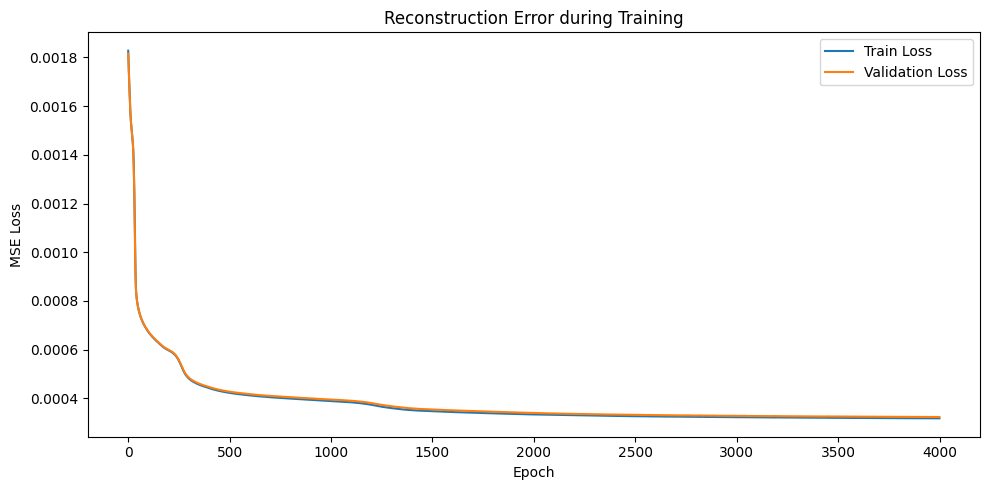

In [ ]:

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Reconstruction Error during Training')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Final Train Loss:", history.history['loss'][-1])
print("Final Val Loss:", history.history['val_loss'][-1])

Final Train Loss: 0.0003175065212417394
Final Val Loss: 0.0003227210254408419
